In [8]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

c:\Users\matth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Load and Merge Data
hpsa_df = pd.read_csv('GitHub Capstone/DS_Capstone_Group_1/data/v2_cleaned/hpsa_need_category_v3.csv')
monte_df = pd.read_csv('GitHub Capstone/DS_Capstone_Group_1/data/v2_cleaned/monte_carlo_simulation_results.csv')
financial_df = pd.read_csv('roi_by_county_v1.csv', index_col=0)

In [10]:
monte_df.insert(0, 'geoid', hpsa_df['geoid'])
df = hpsa_df.merge(monte_df, on="geoid")
df.head()

,geoid_tract,geoid,hpsa_designated,hpsa_need_category,hpsa_need_category_label,diabetes_pct_reduction_mean,diabetes_pct_reduction_p05,diabetes_pct_reduction_p95,high_bp_pct_reduction_mean,high_bp_pct_reduction_p05,high_bp_pct_reduction_p95,high_cholesterol_pct_reduction_mean,high_cholesterol_pct_reduction_p05,high_cholesterol_pct_reduction_p95,asthma_pct_reduction_mean,asthma_pct_reduction_p05,asthma_pct_reduction_p95,no_checkup_pct_reduction_mean,no_checkup_pct_reduction_p05,no_checkup_pct_reduction_p95
0,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032444,0.015547,0.052138,0.094713,0.046653,0.151013,0.122421,0.062349,0.202158,0.024049,0.012419,0.037703,0.377668,0.208467,0.571981
1,1001020100,1001,1.0,1,hpsa_designated_high_need,0.040363,0.020514,0.062889,0.105712,0.051960,0.165784,0.112325,0.058663,0.171148,0.026366,0.012959,0.041388,0.383723,0.215596,0.577626
2,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032769,0.016827,0.053078,0.092074,0.047792,0.146349,0.115946,0.063437,0.183649,0.023594,0.012725,0.036823,0.361315,0.197578,0.551564
3,1001020100,1001,1.0,1,hpsa_designated_high_need,0.030406,0.015351,0.048521,0.094191,0.048619,0.150773,0.127970,0.065797,0.198910,0.021047,0.011126,0.033213,0.380811,0.216822,0.572805
4,1001020100,1001,1.0,1,hpsa_designated_high_need,0.026067,0.012786,0.041901,0.083019,0.043511,0.132988,0.110945,0.058505,0.173601,0.022165,0.011927,0.034781,0.366114,0.210646,0.560115


In [11]:
monte_df

,geoid,diabetes_pct_reduction_mean,diabetes_pct_reduction_p05,diabetes_pct_reduction_p95,high_bp_pct_reduction_mean,high_bp_pct_reduction_p05,high_bp_pct_reduction_p95,high_cholesterol_pct_reduction_mean,high_cholesterol_pct_reduction_p05,high_cholesterol_pct_reduction_p95,asthma_pct_reduction_mean,asthma_pct_reduction_p05,asthma_pct_reduction_p95,no_checkup_pct_reduction_mean,no_checkup_pct_reduction_p05,no_checkup_pct_reduction_p95
0,1001,0.032444,0.015547,0.052138,0.094713,0.046653,0.151013,0.122421,0.062349,0.202158,0.024049,0.012419,0.037703,0.377668,0.208467,0.571981
1,1001,0.040363,0.020514,0.062889,0.105712,0.051960,0.165784,0.112325,0.058663,0.171148,0.026366,0.012959,0.041388,0.383723,0.215596,0.577626
2,1001,0.032769,0.016827,0.053078,0.092074,0.047792,0.146349,0.115946,0.063437,0.183649,0.023594,0.012725,0.036823,0.361315,0.197578,0.551564
3,1001,0.030406,0.015351,0.048521,0.094191,0.048619,0.150773,0.127970,0.065797,0.198910,0.021047,0.011126,0.033213,0.380811,0.216822,0.572805
4,1001,0.026067,0.012786,0.041901,0.083019,0.043511,0.132988,0.110945,0.058505,0.173601,0.022165,0.011927,0.034781,0.366114,0.210646,0.560115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71501,56043,0.029134,0.015201,0.047253,0.077047,0.040116,0.122118,0.108907,0.059121,0.173493,0.023591,0.012323,0.037290,0.338469,0.192208,0.508544
71502,56043,0.027378,0.013698,0.043310,0.070873,0.035698,0.113498,0.101760,0.053416,0.157716,0.024646,0.012342,0.037989,0.328347,0.187681,0.505179
71503,56043,0.033515,0.015767,0.053246,0.082175,0.041287,0.128873,0.111374,0.057609,0.172511,0.024314,0.012642,0.038163,0.342044,0.194917,0.511653
71504,56045,0.027854,0.014308,0.044984,0.080191,0.042299,0.125257,0.106326,0.055716,0.167166,0.022819,0.011550,0.036721,0.320427,0.170550,0.489573


In [12]:
df = df.merge(financial_df, on="geoid")
df.head()

,geoid_tract,geoid,hpsa_designated,hpsa_need_category,hpsa_need_category_label,diabetes_pct_reduction_mean,diabetes_pct_reduction_p05,diabetes_pct_reduction_p95,high_bp_pct_reduction_mean,high_bp_pct_reduction_p05,...,no_checkup_pct_reduction_p05,no_checkup_pct_reduction_p95,county,state,sub_price,roi_mean,roi_std,roi_p10,roi_p50,roi_p90
0,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032444,0.015547,0.052138,0.094713,0.046653,...,0.208467,0.571981,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
1,1001020100,1001,1.0,1,hpsa_designated_high_need,0.040363,0.020514,0.062889,0.105712,0.051960,...,0.215596,0.577626,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
2,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032769,0.016827,0.053078,0.092074,0.047792,...,0.197578,0.551564,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
3,1001020100,1001,1.0,1,hpsa_designated_high_need,0.030406,0.015351,0.048521,0.094191,0.048619,...,0.216822,0.572805,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
4,1001020100,1001,1.0,1,hpsa_designated_high_need,0.026067,0.012786,0.041901,0.083019,0.043511,...,0.210646,0.560115,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997


In [13]:
df.columns

Index(['geoid_tract', 'geoid', 'hpsa_designated', 'hpsa_need_category',
       'hpsa_need_category_label', 'diabetes_pct_reduction_mean',
       'diabetes_pct_reduction_p05', 'diabetes_pct_reduction_p95',
       'high_bp_pct_reduction_mean', 'high_bp_pct_reduction_p05',
       'high_bp_pct_reduction_p95', 'high_cholesterol_pct_reduction_mean',
       'high_cholesterol_pct_reduction_p05',
       'high_cholesterol_pct_reduction_p95', 'asthma_pct_reduction_mean',
       'asthma_pct_reduction_p05', 'asthma_pct_reduction_p95',
       'no_checkup_pct_reduction_mean', 'no_checkup_pct_reduction_p05',
       'no_checkup_pct_reduction_p95', 'county', 'state', 'sub_price',
       'roi_mean', 'roi_std', 'roi_p10', 'roi_p50', 'roi_p90'],
      dtype='str')

In [14]:
# --- STAGE 1: AGGREGATION & SCORING ---

# 1. Aggregate tract data to County level
# We use 'max' for hpsa_need_category to capture the highest need level in the county
county_df = df.groupby('geoid').agg({
    'diabetes_pct_reduction_mean': 'mean',
    'high_bp_pct_reduction_mean': 'mean',
    'high_cholesterol_pct_reduction_mean': 'mean',
    'asthma_pct_reduction_mean': 'mean',
    'no_checkup_pct_reduction_mean': 'mean',
    'roi_mean': 'mean',
    'roi_std': 'mean',
    'hpsa_need_category': 'max' 
}).reset_index()

# 2. Define the Health and Finance columns
health_cols = [
    'diabetes_pct_reduction_mean', 'high_bp_pct_reduction_mean', 
    'high_cholesterol_pct_reduction_mean', 'asthma_pct_reduction_mean',
    'no_checkup_pct_reduction_mean'
]

# 3. Normalize for fair weighting (0 to 1 scale)
scaler = MinMaxScaler()
scaled_health = scaler.fit_transform(county_df[health_cols])
scaled_roi = scaler.fit_transform(county_df[['roi_mean']])

# 4. Create the Target Label (70% Health / 30% Finance)
# Each of the 5 health metrics contributes 14% to the total score
health_score = scaled_health.sum(axis=1) * (0.70 / 5)
finance_score = scaled_roi.flatten() * 0.30
county_df['composite_score'] = health_score + finance_score

# Classify 'Best' as counties in the top 25th percentile
threshold = county_df['composite_score'].quantile(0.75)
county_df['is_best'] = (county_df['composite_score'] >= threshold).astype(int)

In [15]:
# --- STAGE 2: MODEL TRAINING ---

# 1. Select features (Drop scores and geoid to prevent cheating)
# sub_price is excluded as it is a constant (no predictive value)
features = health_cols + ['roi_mean', 'roi_std', 'hpsa_need_category']
X = county_df[features]
y = county_df['is_best']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Generating SHAP Summary Plot...


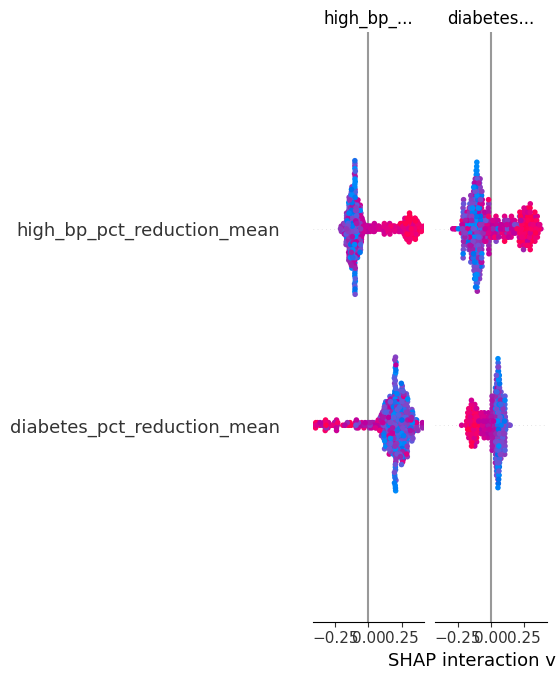

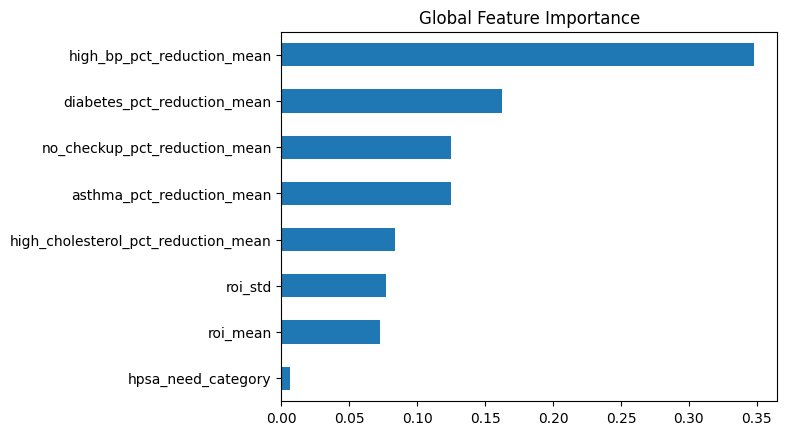

   geoid  composite_score
2   1005         0.760470
5   1011         0.782022
6   1013         0.750224
7   1015         0.703336
8   1017         0.739692


In [16]:
# --- STAGE 3: SHAP ANALYSIS ---

# Calculate SHAP values for the test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# If binary classification, shap_values is a list. Index 1 is the 'Positive' (Best) class.
# Note: In newer versions of SHAP, it might return a single array for binary.
if isinstance(shap_values, list):
    actual_shap = shap_values[1]
else:
    actual_shap = shap_values

# Visual 1: Summary Plot
print("Generating SHAP Summary Plot...")
shap.summary_plot(actual_shap, X_test)

# Visual 2: Feature Importance Bar Chart
feat_importances = pd.Series(model.feature_importances_, index=features)
feat_importances.sort_values().plot(kind='barh', title='Global Feature Importance')
plt.show()

# Final output: Top 5 Counties predicted as 'Best'
predictions = model.predict(X)
county_df['prediction'] = predictions
print(county_df[county_df['prediction'] == 1][['geoid', 'composite_score']].head())